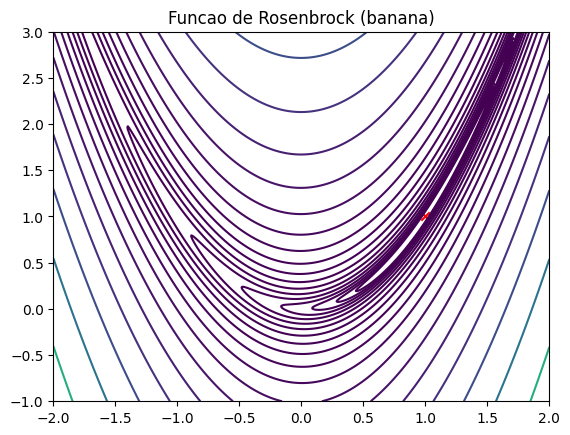

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(x):
    return (1-x[0])**2 + 100*(x[1]-x[0]**2)**2

X, Y = np.meshgrid(np.linspace(-2, 2, 400),
                   np.linspace(-1, 3, 400))
Z = (1-X)**2 + 100*(Y-X**2)**2

plt.contour(X, Y, Z, levels=np.logspace(-0.5, 3.5, 20))
plt.scatter(1,1,c='red',marker='x')
plt.title("Funcao de Rosenbrock (banana)")
plt.show()

In [2]:
from scipy.optimize import minimize

x0 = [0,0]
res = minimize(rosenbrock, x0, method='Nelder-Mead')
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.6861769151759075e-10
             x: [ 1.000e+00  1.000e+00]
           nit: 79
          nfev: 146
 final_simplex: (array([[ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  9.999e-01],
                       [ 1.000e+00,  1.000e+00]]), array([ 3.686e-10,  1.636e-09,  2.022e-09]))

In [3]:
import numpy as np

grad = lambda x : np.array([-2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2),
                            200*(x[1]-x[0]**2)])

res = minimize(rosenbrock,x0, method='BFGS', jac=grad)
print(res)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 7.717288356613562e-13
        x: [ 1.000e+00  1.000e+00]
      nit: 19
      jac: [ 3.928e-06 -2.831e-06]
 hess_inv: [[ 4.948e-01  9.895e-01]
            [ 9.895e-01  1.984e+00]]
     nfev: 24
     njev: 24


In [ ]:
# x + y >= 4
# x - y = 0

# g(x) <= 0
# h(x) == 0

cons = [{'type': 'ineq', 'fun': lambda z: z[0] + z[1] - 4},
        {'type': 'eq', 'fun': lambda z: z[0]-z[1]}]

x0 = [0.0,0.0]

res = minimize(rosenbrock,x0, method='SLSQP', jac=grad, constraints=cons,
               options={'maxiter':300,'ftol':1e-10})
res


 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 401.00000000050835
       x: [ 2.000e+00  2.000e+00]
     nit: 3
     jac: [ 1.602e+03 -4.000e+02]
    nfev: 5
    njev: 3

In [6]:
# x - y = 0
# - x + y <= 0
# x - y <= 0


cons = [{'type': 'ineq', 'fun': lambda z: z[0] + z[1] - 4},
        {'type': 'ineq', 'fun': lambda z: z[0]-z[1]},
        {'type': 'ineq', 'fun': lambda z: -z[0]+z[1]},]

x0 = [0.0,0.0]

res = minimize(rosenbrock,x0, method='COBYLA', jac=grad, constraints=cons)
res

C:\Users\rcpsi\AppData\Local\Temp\ipykernel_7144\3719666019.py:12: RuntimeWarning: Method COBYLA does not use gradient information (jac).
  res = minimize(rosenbrock,x0, method='COBYLA', jac=grad, constraints=cons)


 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 401.0
       x: [ 2.000e+00  2.000e+00]
    nfev: 16
   maxcv: -0.0